In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial import ConvexHull
from random import uniform
from IPython.display import clear_output

from calc import distance, intersection, parallel, angle, orthogonal
from line import Line
from plane import Plane
from point import Point
from solver import solve
from vector import Vector

from funcs import Cube, Parallelepiped, WCCoPrism

In [2]:
def generate_point_in_triangle(A1, A2, A3):
    '''
    A1, A2, A3: Point or array - 2D/3D coordinates of triangle, where we generate a Point uniformly
    '''
    z = np.random.uniform(0., 1., 2)
    l1 = z[0]**0.5
    l2 = z[1]
    
    A1_ = np.array([A1[0], A1[1], A1[2]])
    A2_ = np.array([A2[0], A2[1], A2[2]])
    A3_ = np.array([A3[0], A3[1], A3[2]])
    
    P_new = (1-l1)*A1_ + l1*(1-l2)*A2_ + l1*l2*A3_
    return Point(P_new)

In [3]:
def from_polygon_to_list_of_triangles(vectors):
    '''
    make triangulation of polygon
    
    vectors: np.array of coordinates of points of polygon
    
    return np.array of triangles
    '''
    n = vectors.shape[0]
    fp = vectors[0]
    triangles = []
    for i in range(2, n):
        triangle = np.array([fp, vectors[i-1], vectors[i]])
        triangles.append(triangle)
    return np.array(triangles)


def area_of_triangle_3d(triangle):
    """
    Функция для вычисления площади треугольника в трехмерном пространстве по координатам его вершин.

    Аргументы:
    v1, v2, v3 -- Point or np.darray, содержащие координаты вершин треугольника в трехмерном пространстве.

    Возвращает:
    Площадь треугольника.
    """
    v1 = triangle[0]
    v2 = triangle[1]
    v3 = triangle[2]
    if (isinstance(v1, Line) or isinstance(v2, Line) or isinstance(v3, Line)):
        return 100000
    
    # Вычисляем векторы, соединяющие вершины треугольника.
    a = (v2[0] - v1[0], v2[1] - v1[1], v2[2] - v1[2])
    b = (v3[0] - v1[0], v3[1] - v1[1], v3[2] - v1[2])
    # Вычисляем векторное произведение векторов a и b.
    cross_product = (a[1] * b[2] - a[2] * b[1], a[2] * b[0] - a[0] * b[2], a[0] * b[1] - a[1] * b[0])
    # Вычисляем длину вектора cross_product.
    length = (cross_product[0] ** 2 + cross_product[1] ** 2 + cross_product[2] ** 2)**0.5
    # Вычисляем площадь треугольника.
    area = length / 2
    return area

def area_of_polygon_3d(polygon):
    '''
    get area of polygon
    
    polygon: np.array of coordinates of points of polygon
    
    return: area of polygon
    '''
    #make triangulation
    triangles = from_polygon_to_list_of_triangles(polygon)
    S = 0.
    #for every triangle add area of polygon
    for triangle in triangles:
        S += area_of_triangle_3d(triangle)
    return S
    

def is_point_in_polygon(P, polygon):
    '''
    check if point P is in polygon
    
    P: Point or np.darray
    polygon: np.darray of coordinates of polygon vertices
    
    return True if point is in polygon, False otherwise
    '''
    S = area_of_polygon_3d(polygon) #area of polygon
    S_ = 0 #area of triangles PAB, where A, B - neighbour points of polygon
    
    N_edges = len(polygon)
    for i in range(N_edges-1):
        S_ += area_of_triangle_3d([P, polygon[i], polygon[i+1]])
        
    S_ += area_of_triangle_3d([P, polygon[N_edges-1], polygon[0]])
    
    return abs(S-S_) < 0.0000001

def from_list_points_to_array(points):
    '''
    transform list of Points to array of 3D coordinates
    '''
    vecs = np.zeros((len(points), 3))
    for i in range(len(points)):
        vecs[i] = points[i][0], points[i][1], points[i][2]
    return vecs
    

def proportion_S(triangles):
    '''
    get array of proportion of triangles over the triangle
    
    triangles: list of triangles
    '''
    n_triangles = triangles.shape[0]
    proportions = np.zeros(n_triangles)
    
    for j in range(n_triangles):
        proportions[j] = area_of_triangle_3d(triangles[j])

    return proportions/proportions.sum()


def generations_point_in_polygon(vectors):
    '''
    generate point in polygon
    
    '''
    
    triangles = from_polygon_to_list_of_triangles(vectors)
    proportions = proportion_S(triangles)
    proportions_cumsum = np.cumsum(proportions) #to get prob of put point in one triangle
    
    num = np.random.uniform(0, 1)
    
    k = 0 #number of triangle
    for i in range(len(proportions_cumsum)):
        if num <= proportions_cumsum[i]:
            k = i
            break
    
    point = generate_point_in_triangle(triangles[k][0], triangles[k][1], triangles[k][2])
    return point

In [4]:
def test_generate_linear_intersept(cube=Cube()):
    '''
    возвращает список точек-проекций на плоскость и ее выпуклую оболочку
    '''
    #генерируем вектор нормали
    fi = 2*np.pi*uniform(0, 1)
    teta = np.arccos(2*uniform(0, 1) - 1)
    n = Vector(np.sin(teta)*np.cos(fi), 
               np.sin(teta)*np.sin(fi),
               np.cos(teta))
    
    #берем плоскость с таким вектором нормали и проходящую через 0.
    plane = Plane(Point(0., 0., 0.), n)
    #в этой плоскости надо найти многоугольник-проекцию всех точек куба
    polygon_points_not_ordered = []
    for M in cube.iterable_points:
        line_MP = Line(M, n)
        #P - projection of M on plane
        P = intersection(line_MP, plane)
        polygon_points_not_ordered.append([P[0], P[1], P[2]])
    
    polygon_points_not_ordered = np.array(polygon_points_not_ordered)
    hull = ConvexHull(polygon_points_not_ordered[:, :2])
    return polygon_points_not_ordered, hull

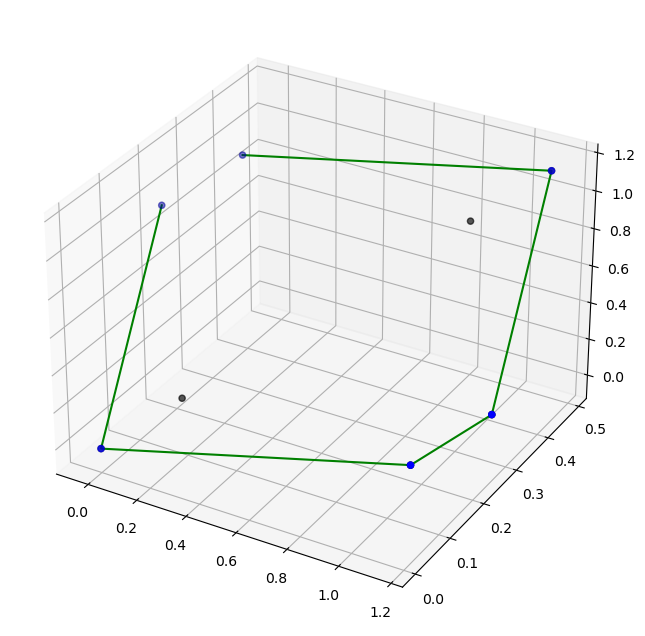

In [5]:
points, hull = test_generate_linear_intersept()

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection = '3d')

ax.scatter(points[:, 0], points[:, 1], points[:, 2], color='black')
ax.scatter(points[hull.vertices][:, 0], points[hull.vertices][:, 1], points[hull.vertices][:, 2], color='blue')
ax.plot(points[hull.vertices][:, 0], points[hull.vertices][:, 1], points[hull.vertices][:, 2], color='green')

### отлично это работает

In [6]:
def generate_linear_intersept(cube=Cube()):
    '''
    generation of length of random linear intersept in cube
    '''
    #генерируем вектор нормали
    fi = 2*np.pi*uniform(0, 1)
    teta = np.arccos(2*uniform(0, 1) - 1)
    n = Vector(np.sin(teta)*np.cos(fi), 
               np.sin(teta)*np.sin(fi),
               np.cos(teta))
    
    #берем плоскость с таким вектором нормали и проходящую через 0.
    plane = Plane(Point(0., 0., 0.), n)
    #в этой плоскости надо найти многоугольник-проекцию всех точек куба
    polygon_points_not_ordered = []
    for M in cube.iterable_points: #проходимся по точкам куба
        line_MP = Line(M, n) #линия-нормаль - через точку куба, которую проецируем
        P = intersection(line_MP, plane) #P - projection of M on plane
        polygon_points_not_ordered.append([P[0], P[1], P[2]]) #добавим точку P в список точек-проекций
    
    polygon_points_not_ordered = np.array(polygon_points_not_ordered) 
    hull = ConvexHull(polygon_points_not_ordered[:, :2]) #берем выпуклую оболочку у проекции многоугольника на Oxy чтобы найти
                                                         #вершины, которые являются тем самым многоугольником-проекцией
    polygon = polygon_points_not_ordered[hull.vertices]  #оставляем только нужные вершины и в нужном порядке
    
    Pns = generations_point_in_polygon(polygon) #генерируем точку в этом многоугольнике-проекции
    linear_intersept_line = Line(Pns, n) # прямая, содержащая этот перехват, проходит через Pns и сонаправлена n
    
    two_points = [] #будем надеяться что будет две точки у концов отрезка
    #будем среди пересечений линии linear_intersept_line искать те, которые пересекают именно грани
    
    for i, pl in enumerate(cube.iterable_planes):
        #check the intersection of generated line and a cube's facets
        X = intersection(linear_intersept_line, pl)
        #need to check is the X inside the facet
        if is_point_in_polygon(X, from_list_points_to_array(cube.iterable_facets[i])):
            two_points.append(X)
    if len(two_points) != 2:
        print('smth went wrong, not 2 points')
        return None
    P1 = two_points[0]
    P2 = two_points[1]
    lin = P1-P2
    
    return (lin[0]**2 + lin[1]**2 + lin[2]**2)**0.5

In [7]:
%%time
#28 minutes
np.random.seed(173)
intersepts_cube = np.zeros(174)
for i in range(1000000):
    temp = generate_linear_intersept()
    if temp is not None:
        ind = round(temp * 100)
        intersepts_cube[ind] += 1
        
np.save('intersepts_cube.npy', intersepts_cube)
clear_output()

Wall time: 40min 53s


In [7]:
intersepts_cube = np.load('intersepts_cube.npy')

C:\Users\lizaconst\AppData\Local\Temp\ipykernel_19492\2286889704.py:1: RuntimeWarning: divide by zero encountered in log
  plt.bar(np.linspace(0, 173, 174), np.log(intersepts_cube))


<BarContainer object of 174 artists>

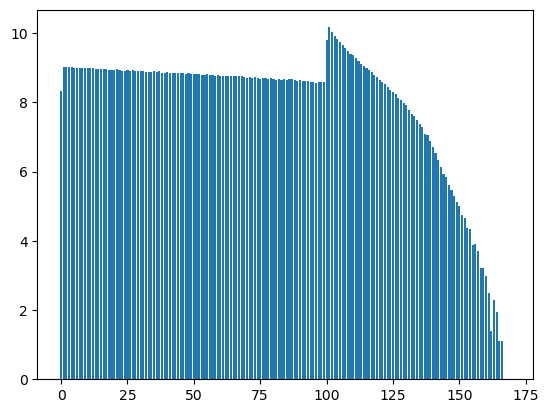

In [8]:
plt.bar(np.linspace(0, 173, 174), np.log(intersepts_cube))

In [12]:
np.linspace(0, 173, 174)/100

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  , 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09,
       1.1 , 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.2 ,
       1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27, 1.28, 1.29, 1.3 , 1.31,
       1.32, 1.33, 1.34, 1.35, 1.36, 1.37, 1.38, 1.39, 1.4 , 1.41, 1.42,
       1.43, 1.44, 1.45, 1.46, 1.47, 1.48, 1.49, 1.

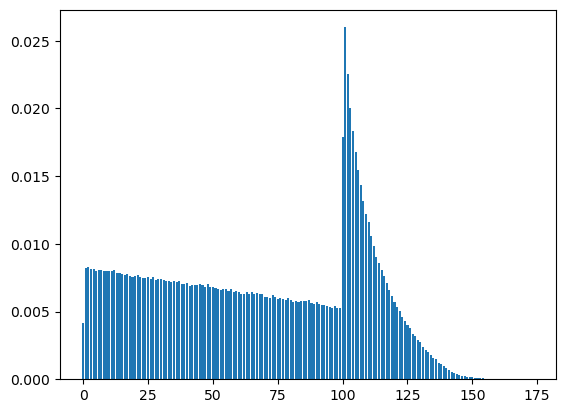

In [18]:
plt.bar(np.linspace(0, 173, 174), intersepts_cube/sum(intersepts_cube))

#x = np.array([0, 0.25, 0.5, 0.75, 1., 1.25, 1.5, 1.75])
#

plt.savefig('intersepts_cube.jpg')

In [10]:
intersepts_cube

array([4.1180e+03, 8.2060e+03, 8.3130e+03, 8.1350e+03, 8.1670e+03,
       7.9620e+03, 8.0520e+03, 8.0410e+03, 8.0000e+03, 8.0290e+03,
       7.9650e+03, 7.9790e+03, 8.0520e+03, 7.8800e+03, 7.8460e+03,
       7.8060e+03, 7.7320e+03, 7.7650e+03, 7.6400e+03, 7.5390e+03,
       7.6050e+03, 7.6940e+03, 7.5280e+03, 7.4430e+03, 7.4520e+03,
       7.5810e+03, 7.3970e+03, 7.5180e+03, 7.3640e+03, 7.4270e+03,
       7.3690e+03, 7.3270e+03, 7.2380e+03, 7.2390e+03, 7.1750e+03,
       7.2680e+03, 7.1540e+03, 7.2460e+03, 7.0050e+03, 7.0250e+03,
       7.1080e+03, 6.9080e+03, 6.9430e+03, 6.9860e+03, 6.9920e+03,
       7.0150e+03, 6.9270e+03, 6.7950e+03, 7.0350e+03, 6.8160e+03,
       6.7830e+03, 6.7700e+03, 6.6920e+03, 6.6270e+03, 6.6350e+03,
       6.6830e+03, 6.5270e+03, 6.6290e+03, 6.4380e+03, 6.5100e+03,
       6.4270e+03, 6.3240e+03, 6.3250e+03, 6.4230e+03, 6.3300e+03,
       6.4120e+03, 6.2850e+03, 6.3750e+03, 6.2730e+03, 6.2640e+03,
       6.0440e+03, 6.0930e+03, 6.0260e+03, 6.1960e+03, 6.0520e

### Параллелепипед

In [10]:
%%time
#28 minutes
np.random.seed(173)
intersepts_tetra = np.zeros(123)
for i in range(1000000):
    temp = generate_linear_intersept(Parallelepiped(0.5, 0.5, 1))
    if temp is not None:
        ind = round(temp * 100)
        intersepts_tetra[ind] += 1
        
np.save('intersepts_tetra.npy', intersepts_tetra)        
clear_output()

Wall time: 52min 45s


In [19]:
intersepts_tetra = np.load('intersepts_tetra.npy')

C:\Users\lizaconst\AppData\Local\Temp\ipykernel_19492\1294894416.py:1: RuntimeWarning: divide by zero encountered in log
  plt.bar(np.linspace(0, 122, 123), np.log(intersepts_tetra))


<BarContainer object of 123 artists>

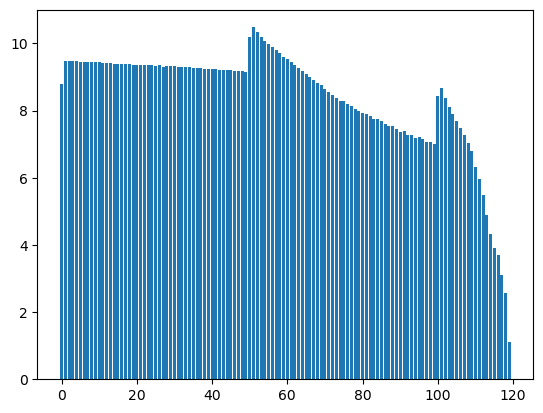

In [20]:
plt.bar(np.linspace(0, 122, 123), np.log(intersepts_tetra))

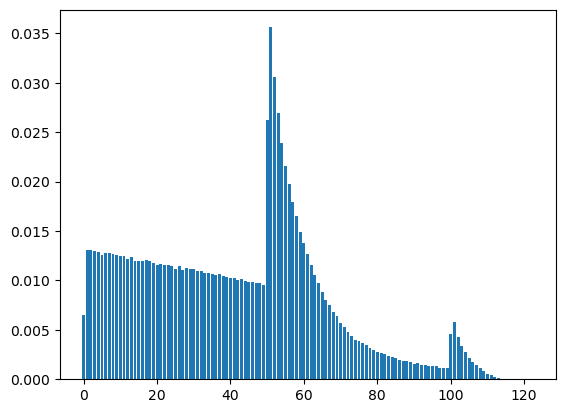

In [21]:
plt.bar(np.linspace(0, 122, 123), intersepts_tetra/sum(intersepts_tetra))

plt.savefig('intersepts_tetra.jpg')

In [11]:
intersepts_tetra

array([6.5180e+03, 1.3170e+04, 1.2955e+04, 1.3029e+04, 1.3082e+04,
       1.2730e+04, 1.2832e+04, 1.2691e+04, 1.2309e+04, 1.2429e+04,
       1.2398e+04, 1.2309e+04, 1.2491e+04, 1.2446e+04, 1.2171e+04,
       1.2090e+04, 1.1972e+04, 1.1980e+04, 1.1963e+04, 1.2096e+04,
       1.1554e+04, 1.1686e+04, 1.1358e+04, 1.1450e+04, 1.1437e+04,
       1.1324e+04, 1.1386e+04, 1.1398e+04, 1.1133e+04, 1.1312e+04,
       1.1067e+04, 1.1019e+04, 1.0816e+04, 1.0741e+04, 1.0574e+04,
       1.0572e+04, 1.0586e+04, 1.0476e+04, 1.0498e+04, 1.0230e+04,
       1.0221e+04, 1.0103e+04, 1.0101e+04, 1.0041e+04, 1.0011e+04,
       9.8770e+03, 9.9940e+03, 9.6600e+03, 9.6140e+03, 9.6940e+03,
       2.5832e+04, 3.5563e+04, 3.0465e+04, 2.6996e+04, 2.4146e+04,
       2.1526e+04, 1.9711e+04, 1.7838e+04, 1.6323e+04, 1.5034e+04,
       1.3596e+04, 1.2396e+04, 1.1562e+04, 1.0525e+04, 9.7770e+03,
       8.8060e+03, 8.0210e+03, 7.3640e+03, 6.8240e+03, 6.2220e+03,
       5.8010e+03, 5.2340e+03, 4.8440e+03, 4.4180e+03, 4.1250e

In [14]:
%%time
#28 minutes
np.random.seed(200)
intersepts_wcco = np.zeros(200)
for i in range(100000):
    temp = generate_linear_intersept(WCCoPrism(r=1, k=2/np.sqrt(3)))
    if temp is not None:
        ind = round(temp * 100)
        intersepts_wcco[ind] += 1

np.save('intersepts_wcco.npy', intersepts_wcco) 
        
clear_output()

Wall time: 5min


<BarContainer object of 200 artists>

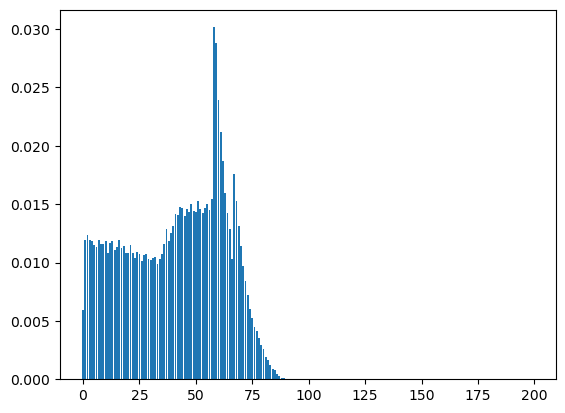

In [15]:
plt.bar(np.linspace(0, 199, 200), intersepts_wcco/sum(intersepts_wcco))